Missing Values:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


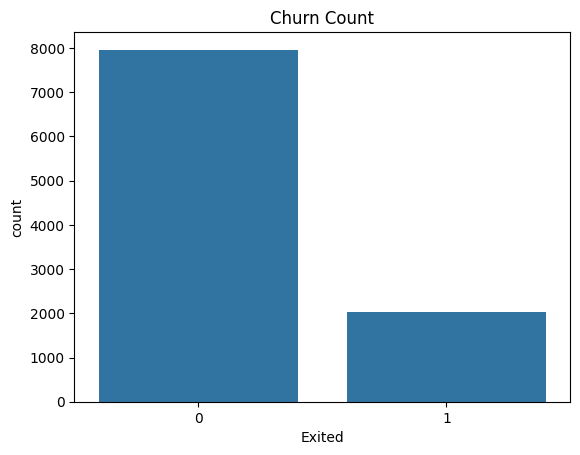

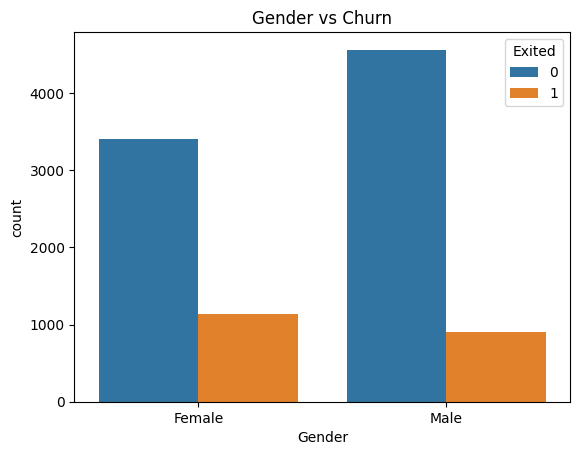

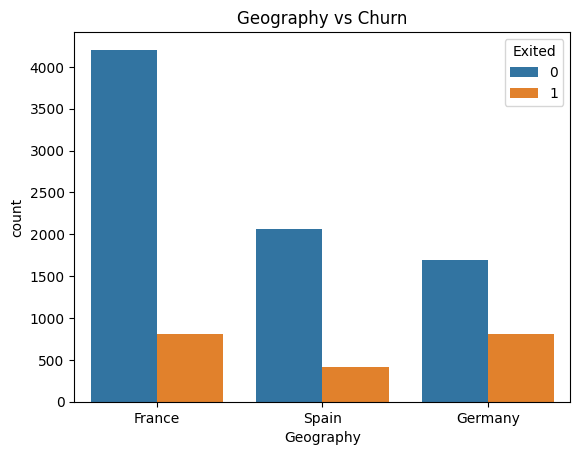

Accuracy: 0.866
Confusion Matrix:
 [[1552   55]
 [ 213  180]]


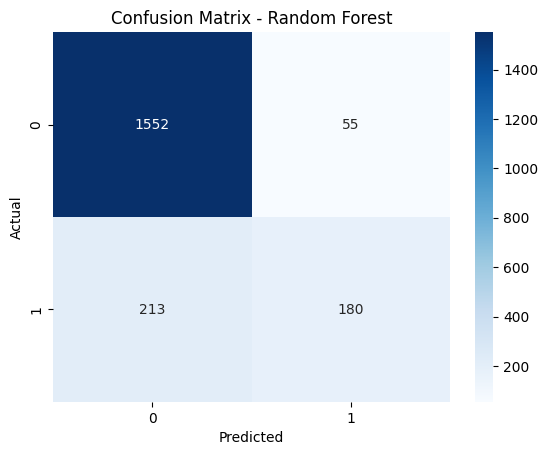


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000


Top 10 Important Features:

             Feature  Importance
2                Age    0.239783
8    EstimatedSalary    0.146638
0        CreditScore    0.144214
4            Balance    0.138613
5      NumOfProducts    0.130255
3             Tenure    0.082427
7     IsActiveMember    0.041110
9  Geography_Germany    0.025711
1             Gender    0.019258
6          HasCrCard    0.018722


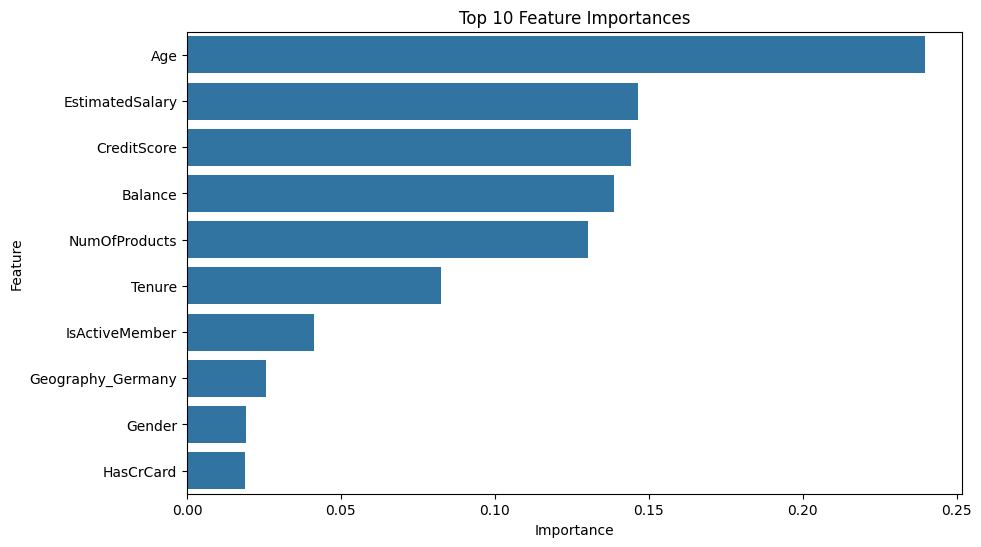

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv("Churn_Modelling.csv")

# Drop unnecessary columns
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)

# Check missing values
print("Missing Values:\n", df.isnull().sum())

# EDA
sns.countplot(x="Exited", data=df)
plt.title("Churn Count")
plt.show()

sns.countplot(x="Gender", hue="Exited", data=df)
plt.title("Gender vs Churn")
plt.show()

sns.countplot(x="Geography", hue="Exited", data=df)
plt.title("Geography vs Churn")
plt.show()

# Encoding
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

# Split features and target
X = df.drop("Exited", axis=1)
y = df["Exited"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model training
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Prediction
y_pred = rf_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Important Features:\n")
print(feature_importance_df.head(10))

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df.head(10))
plt.title("Top 10 Feature Importances")
plt.show()